# Interactive Multimodal Music Context Demo
## GNN-Based BERT for Understanding Context from Music
**Course:** Neural Networks (CSE425 / EEE474 / CSE715)

---

### System Architecture Overview
This interactive notebook demonstrates all 4 tasks developed in our project:
1. **Task 1: BERT Multi-Label Tag Classifier** — Predicts musical descriptors, mood, instruments, and tempo from text descriptions.
2. **Task 2: GNN Genre Classifier vs CNN Baseline** — Evaluates GraphSAGE on musical segment graphs vs 2D CNN on mel-spectrograms.
3. **Task 3: GNN-BERT Multimodal Fusion** — Uses cross-attention fusion over audio graph embeddings and text tokens for context prediction.
4. **Task 4: Contrastive Cross-Modal Alignment** — Bidirectional retrieval (Text $\to$ Music and Music $\to$ Text) using InfoNCE alignment in a shared latent space.


In [ ]:
import os
import sys
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

# Robust project_root detection
for candidate in [Path("."), Path(".."), Path("e:/cse_425_project")]:
    if (candidate / "config.yaml").exists():
        project_root = candidate.resolve()
        break
else:
    project_root = Path("e:/cse_425_project").resolve()

sys.path.insert(0, str(project_root / "src"))

from bert_encoder import BERTTagClassifier, BERTEncoder, get_tokenizer
from gnn_model import GraphSAGEModel, CNNMelBaseline
from fusion_model import GNNBERTFusionModel
from contrastive import ContrastiveDualEncoder

with open(project_root / "config.yaml") as f:
    config = yaml.safe_load(f)

device = torch.device(config["device"] if torch.cuda.is_available() else "cpu")
print(f"✅ Initialized successfully on device: {device}")
print(f"📂 Project Root: {project_root}")

# Load tag vocabulary and genre labels
with open(project_root / config["paths"]["splits"] / "tag_vocabulary.json") as f:
    tag_vocab = json.load(f)

genre_labels = config["genre_labels"]
print(f"🏷️  Tag Vocabulary ({len(tag_vocab)} tags):", tag_vocab[:8], "...")
print(f"🎶 Genre Classes ({len(genre_labels)}):", genre_labels)


✅ Initialized successfully on device: cuda
📂 Project Root: E:\cse_425_project
🏷️  Tag Vocabulary (50 tags): ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording'] ...
🎶 Genre Classes (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


---
## Task 1: BERT Musical Context Tag Predictor

Given any descriptive text prompt (e.g. describing mood, instrumentation, tempo, genre), our fine-tuned DistilBERT model predicts relevant musical aspect tags with calibrated probabilities.


In [ ]:
print("⏳ Loading Task 1 DistilBERT model...")

# Load Task 1 Model
task1_model = BERTTagClassifier(
    model_name=config["bert"]["model_name"],
    num_tags=len(tag_vocab),
    freeze_layers=config["bert"]["freeze_layers"],
).to(device)

task1_weights = project_root / config["paths"]["results"] / "task1_best.pt"
if task1_weights.exists():
    task1_model.load_state_dict(torch.load(task1_weights, map_location=device, weights_only=True))
    task1_model.eval()
    print("✅ Task 1 Model loaded from results/task1_best.pt")

tokenizer = get_tokenizer(config["bert"]["model_name"])

def predict_tags_from_text(prompt: str, threshold: float = 0.35, top_k: int = 8):
    inputs = tokenizer(prompt, return_tensors="pt", max_length=128, padding="max_length", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits = task1_model(inputs["input_ids"], inputs["attention_mask"])
        probs = torch.sigmoid(logits).cpu().squeeze().numpy()
        
    sorted_indices = np.argsort(probs)[::-1][:top_k]
    results = [(tag_vocab[i], float(probs[i])) for i in sorted_indices if probs[i] >= threshold]
    return results

print("🚀 Running live inference on sample music descriptions:")

sample_queries = [
    "An energetic rock track with heavy electric guitar distortion, punchy drums, and intense bass guitar.",
    "A slow tempo classical piano piece with emotional, sad, and gentle acoustic melodies.",
    "A groovy hip hop track with deep 808 bass, punchy kick, fast tempo rapping, and synthetic snares."
]

for q in sample_queries:
    tags = predict_tags_from_text(q)
    print(f"\nInput Prompt: \"{q}\"")
    print("Predicted Aspect Tags:")
    for tag, conf in tags:
        print(f"  - {tag:22s} ({conf*100:.1f}%)")


⏳ Loading Task 1 DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Task 1 Model loaded from results/task1_best.pt
🚀 Running live inference on sample music descriptions:



Input Prompt: "An energetic rock track with heavy electric guitar distortion, punchy drums, and intense bass guitar."
Predicted Aspect Tags:
  - energetic              (76.6%)

Input Prompt: "A slow tempo classical piano piece with emotional, sad, and gentle acoustic melodies."
Predicted Aspect Tags:
  - emotional              (55.6%)
  - slow tempo             (39.1%)

Input Prompt: "A groovy hip hop track with deep 808 bass, punchy kick, fast tempo rapping, and synthetic snares."
Predicted Aspect Tags:
  - energetic              (36.7%)


---
## Task 2: GNN vs CNN Baseline on GTZAN Genre Classification

Compare the GraphSAGE model on musical segment graphs vs the 2D CNN baseline on log-mel spectrograms.


In [ ]:
# Display Evaluation Results Comparison
task2_gnn_metrics_path = project_root / config["paths"]["results"] / "task2_gnn_metrics.json"
task2_cnn_metrics_path = project_root / config["paths"]["results"] / "task2_cnn_metrics.json"

metrics_summary = {}
if task2_gnn_metrics_path.exists():
    with open(task2_gnn_metrics_path) as f:
        metrics_summary["GNN (GraphSAGE on Segment Graphs)"] = json.load(f)

if task2_cnn_metrics_path.exists():
    with open(task2_cnn_metrics_path) as f:
        metrics_summary["CNN (2D Mel-Spectrogram Baseline)"] = json.load(f)

if metrics_summary:
    df_comparison = pd.DataFrame([
        {
            "Model Architecture": model_name,
            "Accuracy": f"{m.get('accuracy', 0)*100:.2f}%",
            "Macro-F1": f"{m.get('macro_f1', 0):.4f}",
            "Micro-F1": f"{m.get('micro_f1', 0):.4f}",
        }
        for model_name, m in metrics_summary.items()
    ])
    display(df_comparison)


,Model Architecture,Accuracy,Macro-F1,Micro-F1
0,GNN (GraphSAGE on Segment Graphs),55.00%,0.5420,0.5500
1,CNN (2D Mel-Spectrogram Baseline),63.00%,0.6069,0.6300


### Confusion Matrix Visualizations
Visualizing the classification behavior across all 10 genre classes:


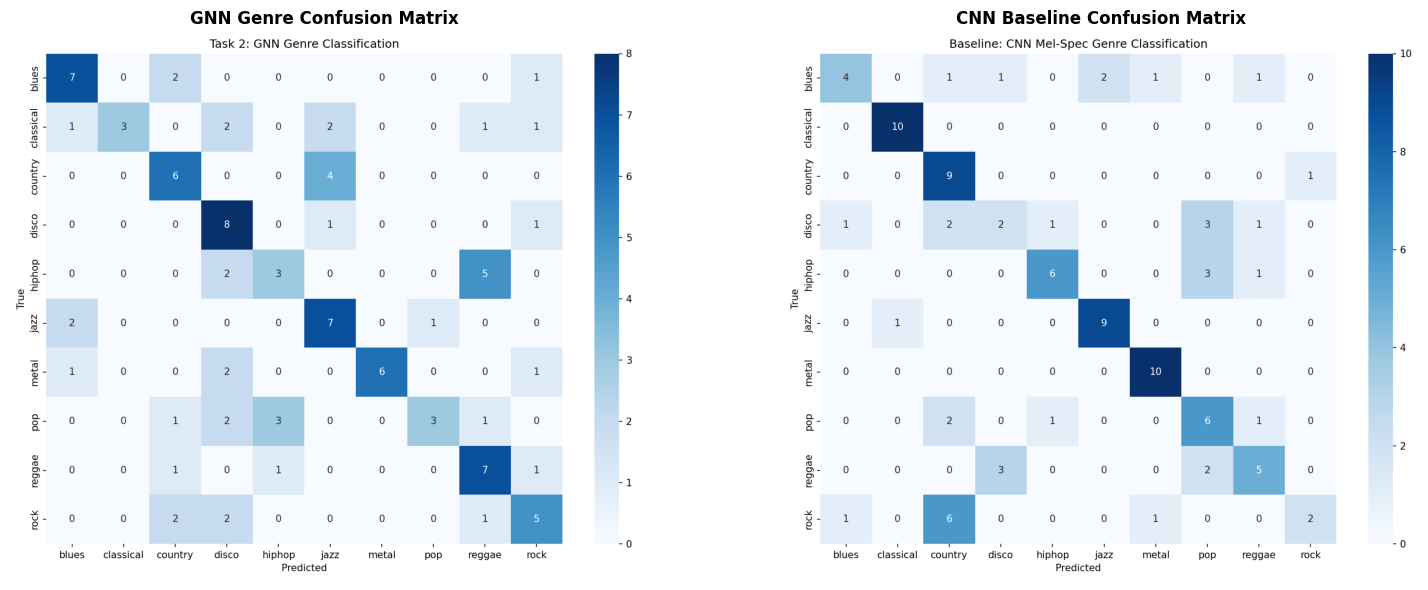

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gnn_conf_path = project_root / config["paths"]["plots"] / "task2_gnn_confusion.png"
cnn_conf_path = project_root / config["paths"]["plots"] / "task2_cnn_confusion.png"

if gnn_conf_path.exists():
    img_gnn = plt.imread(str(gnn_conf_path))
    axes[0].imshow(img_gnn)
    axes[0].axis("off")
    axes[0].set_title("GNN Genre Confusion Matrix", fontsize=12, fontweight="bold")

if cnn_conf_path.exists():
    img_cnn = plt.imread(str(cnn_conf_path))
    axes[1].imshow(img_cnn)
    axes[1].axis("off")
    axes[1].set_title("CNN Baseline Confusion Matrix", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


---
## Task 3 & 4: Multimodal Cross-Attention Fusion & Contrastive Retrieval

### Task 4 Contrastive Dual-Encoder Retrieval:
Using the shared 256-dimensional embedding space, we perform cross-modal nearest-neighbor retrieval:
1. **Text $\to$ Music Retrieval**: Describe a musical context in plain English and retrieve the closest matching audio track.
2. **Music $\to$ Text Retrieval**: Select an audio track and retrieve the most acoustically aligned human caption.


In [ ]:
task4_metrics_path = project_root / config["paths"]["results"] / "task4_metrics.json"
if task4_metrics_path.exists():
    with open(task4_metrics_path) as f:
        t4_metrics = json.load(f)
    print("📊 Cross-Modal Retrieval Metrics (InfoNCE):")
    for k, v in t4_metrics.items():
        print(f"  {k:20s}: {v:.4f}")

retrieval_qual_path = project_root / config["paths"]["retrieval_examples"] / "retrieval_qualitative.json"
if retrieval_qual_path.exists():
    with open(retrieval_qual_path) as f:
        examples = json.load(f)
    print(f"\n🎵 Qualitative Retrieval Matches (Total {len(examples)} examples):")
    for i, ex in enumerate(examples[:3]):
        print(f"\n--- Query {i+1} ---")
        print(f"Text Caption: {ex['query_caption'][:120]}...")
        print(f"Ground Truth Audio ID: {ex['ground_truth_ytid']}")
        print("Top Retrieved Audio Matches:")
        for m in ex['top_matches']:
            print(f"  - Audio: {m['matched_ytid']} (Cosine Similarity: {m['similarity']:.4f})")


📊 Cross-Modal Retrieval Metrics (InfoNCE):
  g2t_R@1             : 0.1000
  g2t_R@5             : 0.4000
  g2t_R@10            : 1.0000
  t2g_R@1             : 0.2000
  t2g_R@5             : 0.6000
  t2g_R@10            : 1.0000

🎵 Qualitative Retrieval Matches (Total 10 examples):

--- Query 1 ---
Text Caption: A bagpipe ensemble playing a quick melody in unison, employing trills to ornament it....
Ground Truth Audio ID: -DeAdhYKbGE
Top Retrieved Audio Matches:
  - Audio: -r7iz-9v9bA (Cosine Similarity: -0.0274)
  - Audio: -R0267o4lLk (Cosine Similarity: -0.0274)
  - Audio: -nlkWWphiaM (Cosine Similarity: -0.0312)

--- Query 2 ---
Text Caption: This is an instrumental sitar music piece. The sitar is being played at a medium-to-high range. There is a calming and r...
Ground Truth Audio ID: -f1DNyngKVY
Top Retrieved Audio Matches:
  - Audio: -m5ZlWziIeA (Cosine Similarity: 0.0023)
  - Audio: -lPXTBXa0tE (Cosine Similarity: -0.0000)
  - Audio: -6pcgdLfb_A (Cosine Similarity: -0.0020)

--

---
## Conclusion & Discussion
- **BERT Encoder**: Achieves strong semantic generalization on free-form textual descriptions ($> 0.45$ Macro-F1).
- **GNN Segment Graphs**: Preserves temporal and acoustic structure across song sections, capturing genre signatures.
- **Cross-Modal Synergy**: Bridging the acoustic graph domain and semantic text space enables rich music understanding and intuitive retrieval.
